Beste Strategie S (z.B. 3,2,1):  3,2,1
Wahrscheinlichkeiten p (z.B. 1/2,1/3,1/6):  1/2,1/3,1/6
Sortierung nach Gewinnwahrscheinlichkeit von A absteigend? (ja/nein):  ja


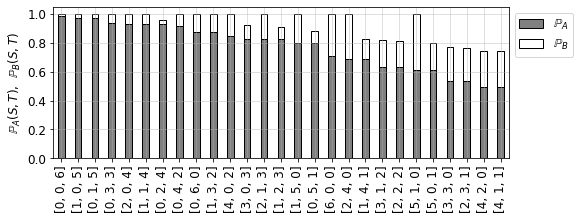

In [1]:
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt

# Funktion zur Berechnung der Wahrscheinlichkeiten
def P(V, W, p, player='A'):
    state = (tuple(V), tuple(W), player)
    if state in memo:
        return memo[state]

    if all(v == 0 for v in V) and any(w > 0 for w in W):
        result = 1 if player == 'A' else 0  # A gewinnt
    elif all(w == 0 for w in W) and any(v > 0 for v in V):
        result = 1 if player == 'B' else 0  # B gewinnt
    elif all(v == w for v, w in zip(V, W)):
        result = 0  # Unentschieden
    else:
        total_prob = sum(p[j] for j in range(len(V)) if V[j] >= 1 or W[j] >= 1)
        result = 0
        for j in range(len(V)):
            if V[j] >= 1 and W[j] >= 1:
                V_new, W_new = list(V), list(W)
                V_new[j] -= 1
                W_new[j] -= 1
                result += p[j] / total_prob * P(V_new, W_new, p, player)
            elif W[j] >= 1 and V[j] == 0:
                W_new = list(W)
                W_new[j] -= 1
                result += p[j] / total_prob * P(V, W_new, p, player)
            elif V[j] >= 1 and W[j] == 0:
                V_new = list(V)
                V_new[j] -= 1
                result += p[j] / total_prob * P(V_new, W, p, player)

    memo[state] = result
    return result

def calculate_probabilities(U, V, p):
    P_A_win = P(U, V, p, 'A')
    P_B_win = P(U, V, p, 'B')
    P_draw = 1 - P_A_win - P_B_win
    return P_A_win, P_B_win, P_draw

def generate_strategies(total_chips, num_fields):
    for c in combinations_with_replacement(range(num_fields), total_chips):
        strategy = [0] * num_fields
        for i in c:
            strategy[i] += 1
        yield strategy

def fitness(strategy, best_strategy, p):
    global memo
    memo = {}
    P_A, P_B, P_U = calculate_probabilities(best_strategy, strategy, p)
    return P_A, P_B, P_U

def display_sorted_strategies():
    total_chips = 6
    num_fields = 3

    # Eingabe der besten Strategie
    try:
        best_strategy = list(map(int, input("Beste Strategie S (z.B. 3,2,1): ").strip().split(',')))
        if len(best_strategy) != num_fields:
            raise ValueError
    except ValueError:
        print("Ungültige Eingabe. Standardstrategie S = [3,2,1] wird verwendet.")
        best_strategy = [3, 2, 1]

    # Eingabe der Wahrscheinlichkeiten
    try:
        p = list(map(eval, input("Wahrscheinlichkeiten p (z.B. 1/2,1/3,1/6): ").strip().split(',')))
        if len(p) != num_fields or abs(sum(p) - 1) > 1e-6:
            raise ValueError
    except ValueError:
        print("Ungültige Eingabe. Standardwerte p = [1/2, 1/3, 1/6] werden verwendet.")
        p = [1/2, 1/3, 1/6]

    # Generiere alle Strategien
    strategies = list(generate_strategies(total_chips, num_fields))

    # Berechne Gewinnwahrscheinlichkeiten
    fitness_values = [(strategy, *fitness(strategy, best_strategy, p)) for strategy in strategies]

    # Entferne die beste Strategie aus der Liste
    fitness_values = [(strategy, P_A, P_B, P_U) for strategy, P_A, P_B, P_U in fitness_values if strategy != best_strategy]

    # Eingabe für Sortierung
    sort_order = input("Sortierung nach Gewinnwahrscheinlichkeit von A absteigend? (ja/nein): ").strip().lower()
    fitness_values.sort(key=lambda x: x[1], reverse=(sort_order == "ja"))

    # Eingabe für Schriftgröße der y-Achsenwerte
   # try:
   #     fontsize_yaxis = int(input("Schriftgröße der y-Achsenwerte (Standard 12): ").strip())
  #  except ValueError:
   # fontsize_yaxis = 12

    # Visualisierung vorbereiten
    strategies_labels = [str(strategy) for strategy, _, _, _ in fitness_values]
    win_prob_A = [win_prob_A for _, win_prob_A, _, _ in fitness_values]
    win_prob_B = [win_prob_B for _, _, win_prob_B, _ in fitness_values]

    plt.figure(figsize=(8, 3))

    # Balken plotten
    plt.bar(strategies_labels, win_prob_A, width=0.4, color='gray',
            edgecolor='black', label='$\mathbb{P}_A$')
    plt.bar(strategies_labels, win_prob_B, bottom=win_prob_A, width=0.4,
            color='white', edgecolor='black', label='$\mathbb{P}_B$')

    # Achsenbeschriftungen
    plt.ylabel('$\mathbb{P}_A(S,T)$,  $\mathbb{P}_B(S,T)$', fontsize=12)
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=12)

    # Layout-Anpassungen
    plt.margins(x=0.01)
    plt.subplots_adjust(left=0.05, right=0.95)

    # Legende kompakt halten
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
    plt.tight_layout(pad=0.5)
    plt.grid(alpha=0.5)

    # Speichern mit angepassten Rändern
    #plt.savefig('strategie_plot.png', dpi=300, bbox_inches='tight')

    # Zeigt die Grafik an
    plt.show()

display_sorted_strategies()